<a href="https://colab.research.google.com/github/merinrose4007/DSA-class-activity/blob/main/Kmeans_Hierarchical_Iris_Merin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = sns.load_dataset('iris')

In [ ]:
data.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
data.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
num_cols = data.select_dtypes(np.number)

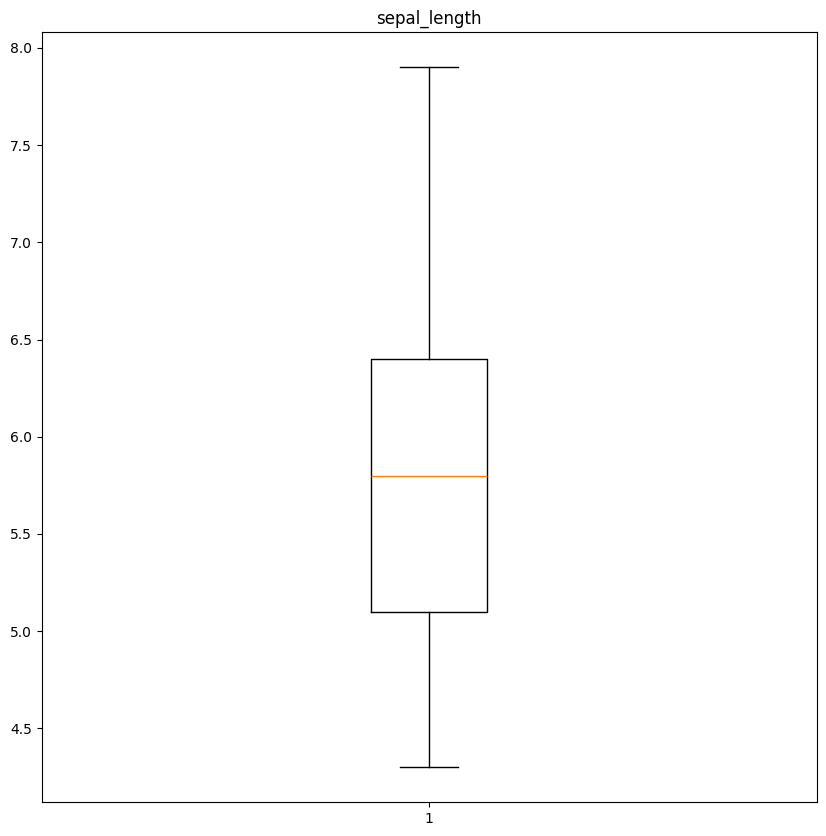

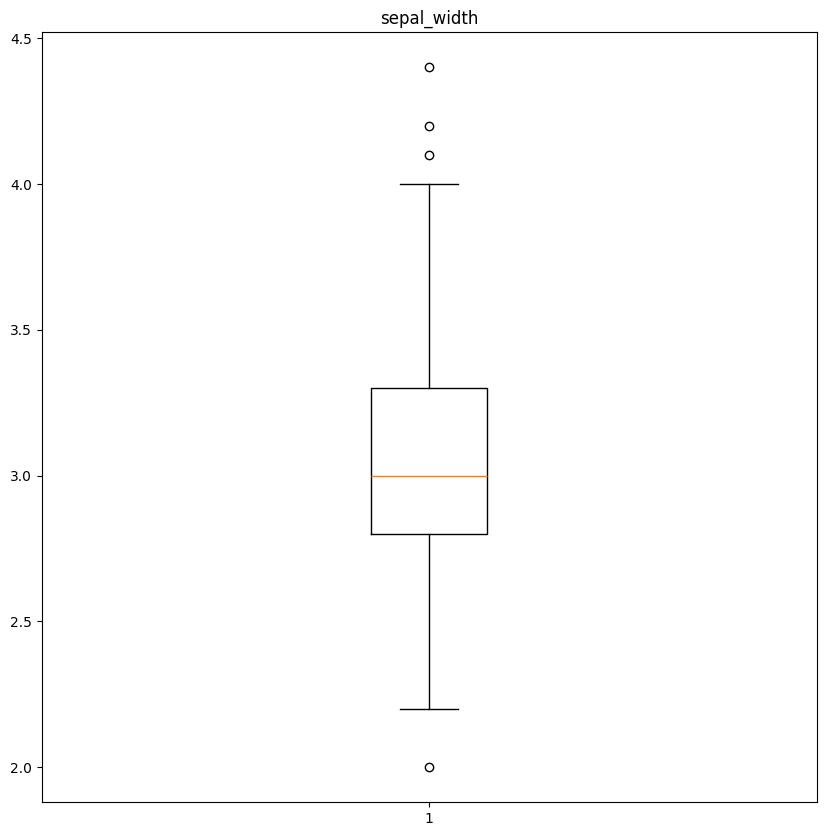

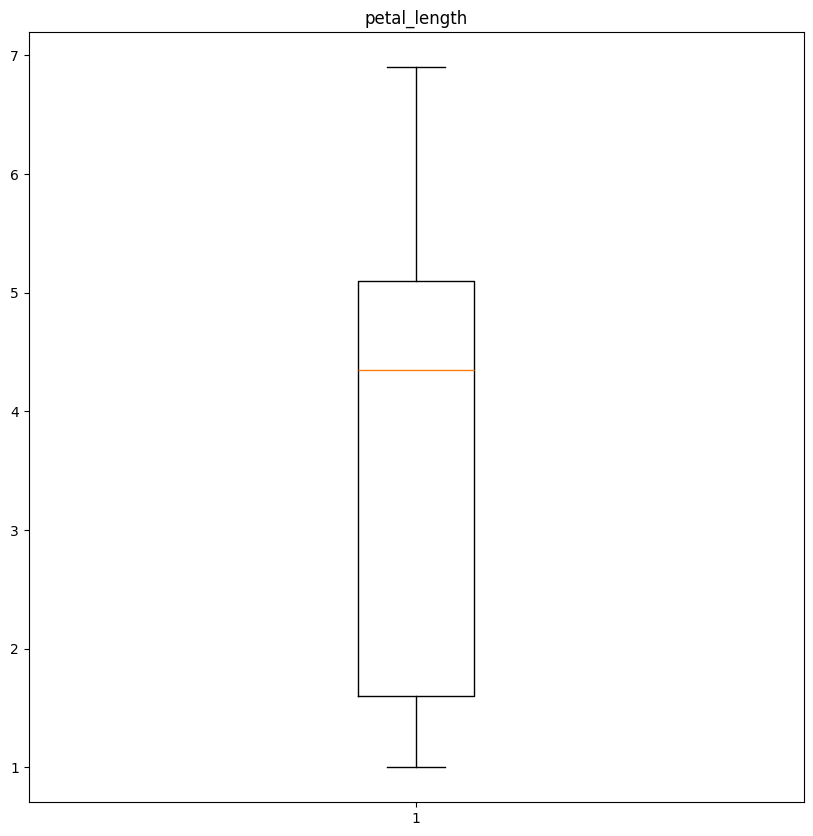

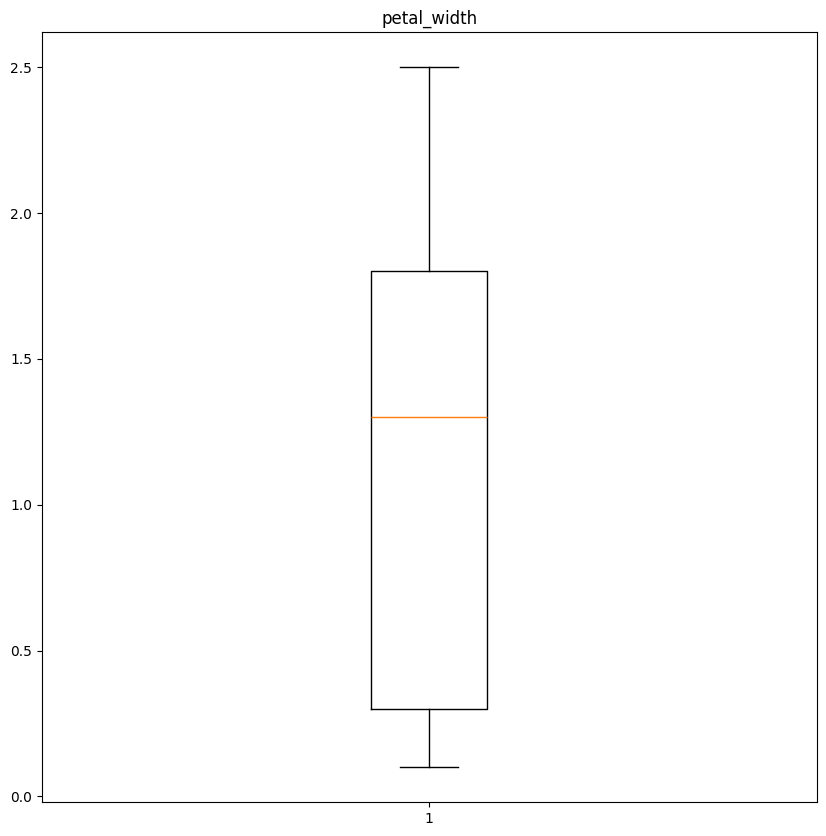

In [ ]:
for i in num_cols:
  plt.figure(figsize= (10,10))
  plt.boxplot(data[i])
  plt.title(i)

In [ ]:
q1 = np.quantile(data['sepal_width'], 0.25)
q3 = np.quantile(data['sepal_width'], 0.75)
iqr = q3 - q1
lower_bound = q3 +(1.5*iqr)
upper_bound = q1 - (1.5*iqr)

In [ ]:
data['sepal_width'] = data['petal_width'].clip(lower = lower_bound, upper = upper_bound)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])

In [ ]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,2.084333,3.758000,1.199333,1.000000
std,0.828066,0.096262,1.765298,0.762238,0.819232
min,4.300000,2.050000,1.000000,0.100000,0.000000
25%,5.100000,2.050000,1.600000,0.300000,0.000000
50%,5.800000,2.050000,4.350000,1.300000,1.000000
75%,6.400000,2.050000,5.100000,1.800000,2.000000
max,7.900000,2.500000,6.900000,2.500000,2.000000


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>],
       [<Axes: title={'center': 'species'}>, <Axes: >]], dtype=object)

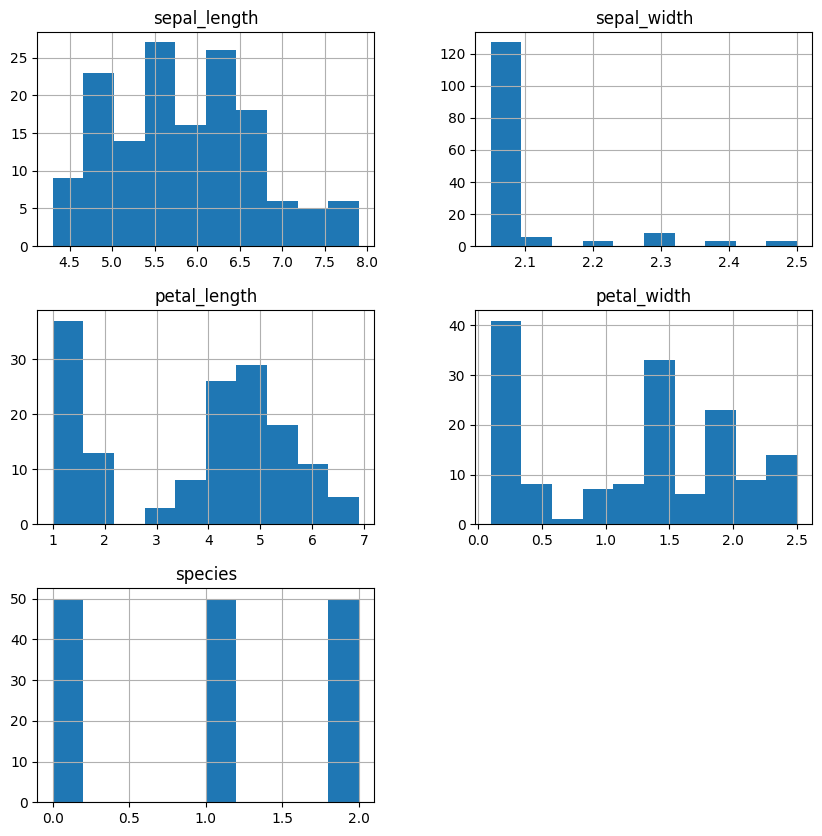

In [ ]:
data.hist(figsize = (10,10))

In [ ]:
corr_matrix = data.corr()
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,0.384512,0.871754,0.817941,0.782561
sepal_width,0.384512,1.000000,0.403295,0.543177,0.438289
petal_length,0.871754,0.403295,1.000000,0.962865,0.949035
petal_width,0.817941,0.543177,0.962865,1.000000,0.956547
species,0.782561,0.438289,0.949035,0.956547,1.000000


In [ ]:
X = data[['petal_length', 'sepal_length', 'petal_width', 'sepal_width']]

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[600.0000000000003,
 257.56152912687435,
 112.83089048907713,
 76.19039347196332,
 61.60858015257889,
 46.19460781938972,
 41.52161232559699,
 35.5403251746184,
 31.409425342852025,
 29.15306280343009]

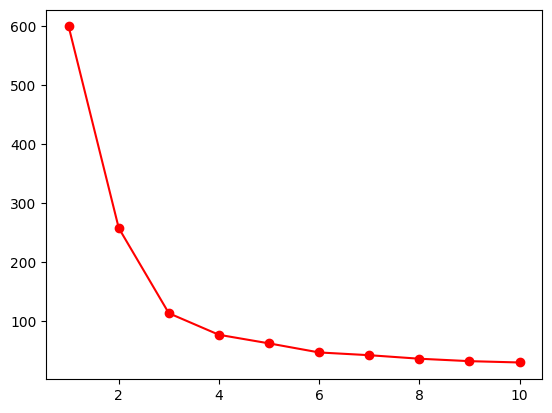

In [ ]:
plt.plot(range(1,11), wcss, color = 'red', marker = 'o')

In [ ]:
data1 = data.copy()

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
kmeans.fit(X)
data1['Cluster'] = kmeans.labels_
data1.head(200)

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,2.05,1.4,0.2,0,1
1,4.9,2.05,1.4,0.2,0,1
2,4.7,2.05,1.3,0.2,0,1
3,4.6,2.05,1.5,0.2,0,1
4,5.0,2.05,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,2.30,5.2,2.3,2,0
146,6.3,2.05,5.0,1.9,2,2
147,6.5,2.05,5.2,2.0,2,2
148,6.2,2.30,5.4,2.3,2,0


In [ ]:
scaler.inverse_transform(kmeans.cluster_centers_)

array([[5.75294118, 6.75882353, 2.33529412, 2.33529412],
       [1.5962963 , 5.00555556, 0.3037037 , 2.05      ],
       [4.80632911, 6.21898734, 1.56708861, 2.05379747]])

In [ ]:
data.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
summary = data1.groupby('Cluster')[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].mean()
print(summary)

         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0            6.758824     2.335294      5.752941     2.335294
1            5.005556     2.050000      1.596296     0.303704
2            6.218987     2.053797      4.806329     1.567089


In [ ]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)
score = silhouette_score(X, labels)
print(score)

0.6220972015703354


In [ ]:
data1.head()

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,2.05,1.4,0.2,0,1
1,4.9,2.05,1.4,0.2,0,1
2,4.7,2.05,1.3,0.2,0,1
3,4.6,2.05,1.5,0.2,0,1
4,5.0,2.05,1.4,0.2,0,1


In [ ]:
new_customer = np.array([[5.1,	2.05,	1.4,	0.2]])
new_customer_scaled = scaler.transform(new_customer)
cluster_label = kmeans.predict(new_customer_scaled)
print(cluster_label)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

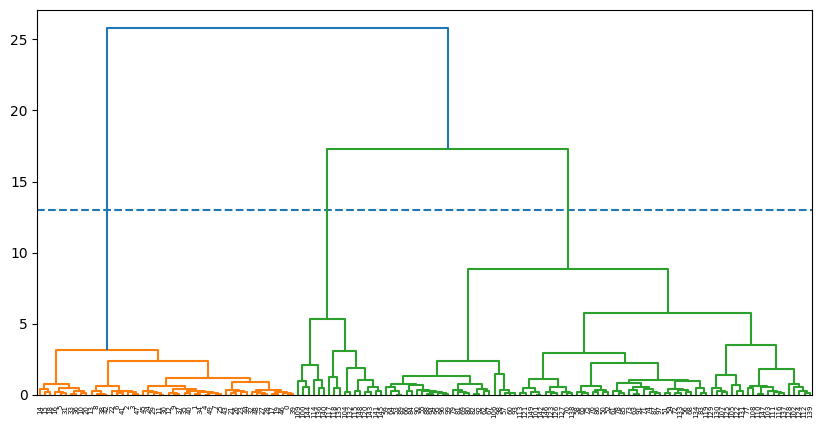

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
merging = linkage(X, method = 'ward')
plt.figure(figsize=(10,5))
plt.axhline(y = 13, ls = '--')
dendrogram(merging,)
plt.show

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')
new_cluster_labels = agg_hc.fit_predict(X)
new_cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0])

In [ ]:
score = silhouette_score(X, new_cluster_labels)
print(score)

0.617696006737893


In [ ]:
data1['agg_hc_clusters'] = new_cluster_labels
data1

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster,agg_hc_clusters
0,5.1,2.05,1.4,0.2,0,1,1
1,4.9,2.05,1.4,0.2,0,1,1
2,4.7,2.05,1.3,0.2,0,1,1
3,4.6,2.05,1.5,0.2,0,1,1
4,5.0,2.05,1.4,0.2,0,1,1
...,...,...,...,...,...,...,...
145,6.7,2.30,5.2,2.3,2,0,2
146,6.3,2.05,5.0,1.9,2,2,0
147,6.5,2.05,5.2,2.0,2,2,0
148,6.2,2.30,5.4,2.3,2,0,2


In [ ]:
data1['Cluster'].value_counts()

,count
Cluster,
2,79
1,54
0,17


In [ ]:
data1['agg_hc_clusters'].value_counts()

,count
agg_hc_clusters,
0,83
1,50
2,17


In [ ]:
data['species'].value_counts()

,count
species,
0,50
1,50
2,50
